In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import collections
from scipy.spatial.distance import cdist
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

RAW = '../data/01_raw/'
train = pd.read_csv(RAW + 'train_raw.csv').dropna(subset=['protein_sequence', 'tm']).copy()
train['seq_len'] = train['protein_sequence'].str.len()
print(f'train: {len(train)} sequences')

train: 31390 sequences


## Length bucket distribution

Mutant clusters must live within the same length bucket.

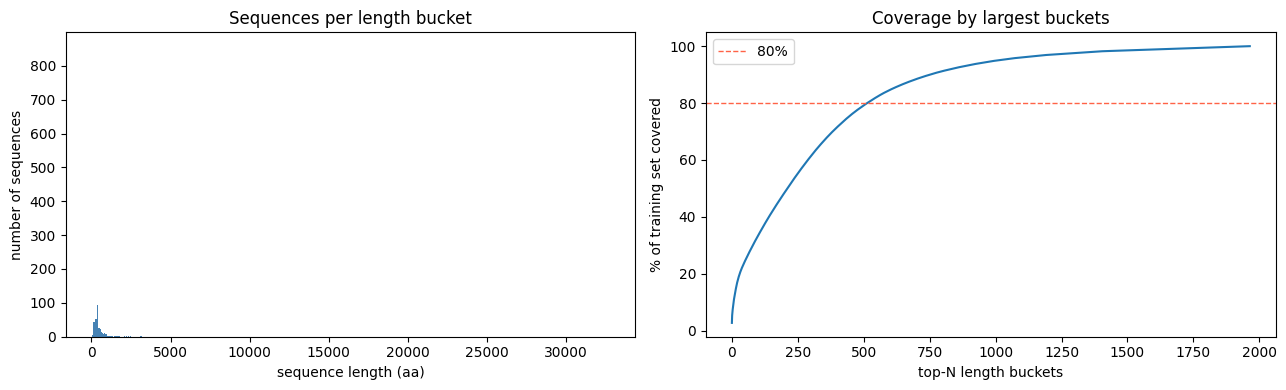

Total length buckets: 1965
Buckets with >1 sequence: 1394 (30819 sequences)
Largest bucket: length=164, n=856

Top 10 buckets by size:
seq_len
164    856
231    828
148    370
155    274
448    250
455    245
157    232
268    224
246    193
159    172


In [2]:
bucket_sizes = train['seq_len'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(bucket_sizes.index, bucket_sizes.values, width=1, color='steelblue', linewidth=0)
ax.set_xlabel('sequence length (aa)')
ax.set_ylabel('number of sequences')
ax.set_title('Sequences per length bucket')

ax = axes[1]
cumulative = np.cumsum(sorted(bucket_sizes.values, reverse=True))
ax.plot(cumulative / len(train) * 100)
ax.set_xlabel('top-N length buckets')
ax.set_ylabel('% of training set covered')
ax.set_title('Coverage by largest buckets')
ax.axhline(80, color='tomato', linestyle='--', linewidth=1, label='80%')
ax.legend()

plt.tight_layout()
plt.show()

multi_seq_buckets = bucket_sizes[bucket_sizes > 1]
print(f'Total length buckets: {len(bucket_sizes)}')
print(f'Buckets with >1 sequence: {len(multi_seq_buckets)} ({multi_seq_buckets.sum()} sequences)')
print(f'Largest bucket: length={bucket_sizes.idxmax()}, n={bucket_sizes.max()}')
print('\nTop 10 buckets by size:')
print(bucket_sizes.nlargest(10).to_string())

## Vectorized Hamming search

For each length bucket with >1 sequence, compute all-pairs Hamming distance using numpy/scipy.
Pairs within the mutation threshold are edges in a graph; connected components are clusters.

In [3]:
# max mutations to consider two sequences as mutants of one another
# expressed as absolute count — adjust to explore different thresholds
MAX_MUTATIONS = 10

def find_cluster_edges(seqs: list[str], max_mutations: int) -> list[tuple[int, int, int]]:
    """Returns (i, j, n_mutations) for all pairs within threshold."""
    n = len(seqs)
    if n < 2:
        return []
    L = len(seqs[0])
    mat = np.frombuffer(b''.join(s.encode('ascii') for s in seqs), dtype=np.uint8).reshape(n, L)
    # hamming returns fraction — multiply by L for raw count
    dists = (cdist(mat, mat, metric='hamming') * L).astype(int)
    ii, jj = np.where((dists > 0) & (dists <= max_mutations))
    # upper triangle only
    mask = ii < jj
    return list(zip(ii[mask].tolist(), jj[mask].tolist(), dists[ii[mask], jj[mask]].tolist()))


# run across all length buckets
all_edges = []   # (global_idx_i, global_idx_j, n_mutations)

for length, group in train.groupby('seq_len'):
    if len(group) < 2:
        continue
    seqs = group['protein_sequence'].tolist()
    local_edges = find_cluster_edges(seqs, MAX_MUTATIONS)
    if local_edges:
        global_idx = group.index.tolist()
        for li, lj, nm in local_edges:
            all_edges.append((global_idx[li], global_idx[lj], nm))

print(f'Found {len(all_edges)} within-threshold pairs (≤{MAX_MUTATIONS} mutations)')

Found 894778 within-threshold pairs (≤10 mutations)


## Connected components = clusters

In [4]:
n_seqs = len(train)
idx_map = {v: i for i, v in enumerate(train.index)}

if all_edges:
    rows = [idx_map[e[0]] for e in all_edges]
    cols = [idx_map[e[1]] for e in all_edges]
    data = [1] * len(all_edges)
    graph = csr_matrix((data + data, (rows + cols, cols + rows)), shape=(n_seqs, n_seqs))
    n_components, labels = connected_components(graph, directed=False)
else:
    n_components, labels = n_seqs, np.arange(n_seqs)

train['cluster_id'] = labels

# clusters with >1 member
cluster_sizes = pd.Series(labels).value_counts()
multi_clusters = cluster_sizes[cluster_sizes > 1]
print(f'Connected components: {n_components}')
print(f'Clusters with >1 sequence: {len(multi_clusters)}')
print(f'Sequences in multi-member clusters: {multi_clusters.sum()} ({multi_clusters.sum()/len(train)*100:.1f}% of train)')
print(f'Largest cluster: {multi_clusters.max()} sequences')

Connected components: 24602
Clusters with >1 sequence: 312
Sequences in multi-member clusters: 7100 (22.6% of train)
Largest cluster: 816 sequences


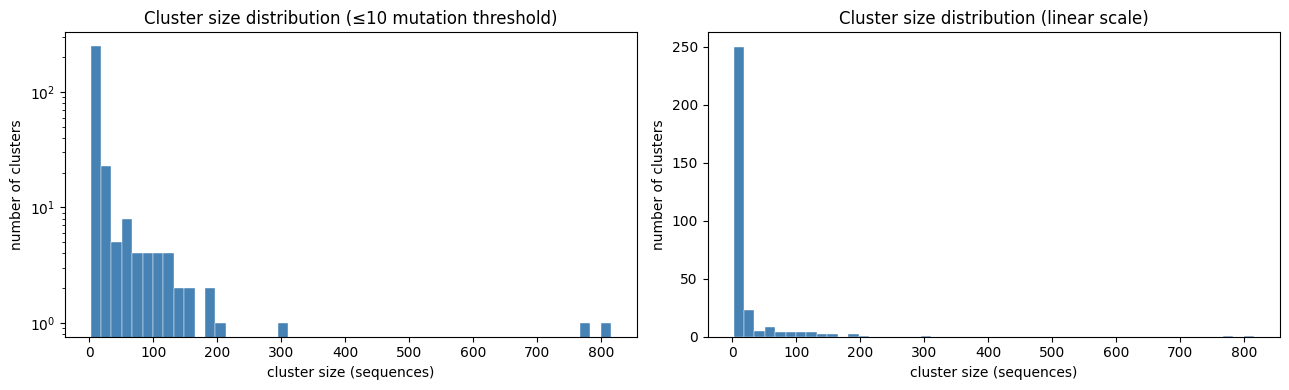

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(multi_clusters.values, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xlabel('cluster size (sequences)')
ax.set_ylabel('number of clusters')
ax.set_title(f'Cluster size distribution (≤{MAX_MUTATIONS} mutation threshold)')
ax.set_yscale('log')

ax = axes[1]
ax.hist(multi_clusters.values, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xlabel('cluster size (sequences)')
ax.set_ylabel('number of clusters')
ax.set_title('Cluster size distribution (linear scale)')

plt.tight_layout()
plt.show()

## Tm spread within clusters

Clusters where sequences have different Tm values are the useful training signal.

Clusters analysed: 312
Median Tm range within cluster: 5.0°C
Clusters with Tm range > 10°C: 105


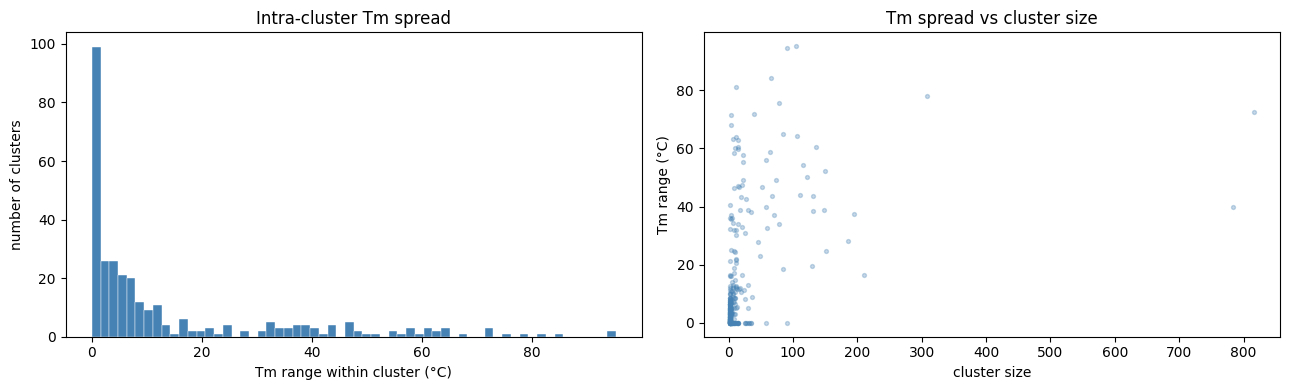

In [6]:
clustered = train[train['cluster_id'].isin(multi_clusters.index)].copy()

cluster_stats = clustered.groupby('cluster_id').agg(
    n=('tm', 'count'),
    tm_min=('tm', 'min'),
    tm_max=('tm', 'max'),
    tm_std=('tm', 'std'),
    seq_len=('seq_len', 'first'),
    n_sources=('data_source', 'nunique'),
).reset_index()
cluster_stats['tm_range'] = cluster_stats['tm_max'] - cluster_stats['tm_min']

print(f'Clusters analysed: {len(cluster_stats)}')
print(f'Median Tm range within cluster: {cluster_stats["tm_range"].median():.1f}°C')
print(f'Clusters with Tm range > 10°C: {(cluster_stats["tm_range"] > 10).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(cluster_stats['tm_range'], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Tm range within cluster (°C)')
ax.set_ylabel('number of clusters')
ax.set_title('Intra-cluster Tm spread')

ax = axes[1]
ax.scatter(cluster_stats['n'], cluster_stats['tm_range'], alpha=0.3, s=8, color='steelblue')
ax.set_xlabel('cluster size')
ax.set_ylabel('Tm range (°C)')
ax.set_title('Tm spread vs cluster size')

plt.tight_layout()
plt.show()

## Largest / most informative clusters

In [7]:
print('=== Top 10 clusters by size ===')
print(cluster_stats.nlargest(10, 'n')[['cluster_id', 'n', 'seq_len', 'tm_min', 'tm_max', 'tm_range', 'n_sources']].to_string(index=False))
print()
print('=== Top 10 clusters by Tm range ===')
print(cluster_stats.nlargest(10, 'tm_range')[['cluster_id', 'n', 'seq_len', 'tm_min', 'tm_max', 'tm_range', 'n_sources']].to_string(index=False))

=== Top 10 clusters by size ===
 cluster_id   n  seq_len  tm_min  tm_max  tm_range  n_sources
      14046 816      164    -1.0    71.6      72.6         58
      13731 783      231    20.0    59.8      39.8         16
      11564 308      148     0.1    78.3      78.2         19
      14645 211      455    54.5    71.0      16.5          1
      13180 195      155    25.0    62.6      37.6          9
      13890 185      157    25.0    53.0      28.0          4
      21418 151      246    33.0    57.8      24.8          1
        943 150       96     5.5    57.8      52.3          4
      18459 148      170    25.0    64.0      39.0          4
       9744 135      537    25.0    85.5      60.5          2

=== Top 10 clusters by Tm range ===
 cluster_id   n  seq_len  tm_min  tm_max  tm_range  n_sources
      16688 104      144     0.1    95.3      95.2          4
      12267  91      100     0.0    94.4      94.4          5
      22130  65      154     0.0    84.2      84.2          2
 

In [8]:
# inspect the largest cluster in detail
top_cluster_id = cluster_stats.nlargest(1, 'n')['cluster_id'].values[0]
top_cluster = clustered[clustered['cluster_id'] == top_cluster_id].copy()

# find the local wildtype: sequence with highest Tm
local_wt = top_cluster.loc[top_cluster['tm'].idxmax(), 'protein_sequence']
top_cluster['n_mut_from_local_wt'] = top_cluster['protein_sequence'].apply(
    lambda s: sum(a != b for a, b in zip(s, local_wt)) if len(s) == len(local_wt) else np.nan
)
top_cluster['delta_tm_from_local_wt'] = top_cluster['tm'] - top_cluster['tm'].max()

print(f'Largest cluster: {len(top_cluster)} sequences, length {top_cluster["seq_len"].iloc[0]} aa')
print(f'Tm range: {top_cluster["tm"].min():.1f} – {top_cluster["tm"].max():.1f}°C')
print(f'Data sources: {top_cluster["data_source"].unique()}')
print()
print(top_cluster[['seq_id', 'tm', 'pH', 'n_mut_from_local_wt', 'delta_tm_from_local_wt', 'data_source']]
      .sort_values('n_mut_from_local_wt').head(20).to_string(index=False))

Largest cluster: 816 sequences, length 164 aa
Tm range: -1.0 – 71.6°C
Data sources: <StringArray>
[          '10.1021/bi00535a054',                             nan,
              '10.1038/334406a0',           '10.1021/bi00159a009',
             '10.1021/bi9915519',        '10.1002/pro.5560070117',
         '10.1002/bip.360261104',        '10.1002/pro.5560070326',
         '10.1073/pnas.92.2.452',        '10.1002/pro.5560021221',
  '10.1016/0022-2836(91)80181-s',           '10.1021/bi00219a037',
        '10.1002/pro.5560021222',           '10.1110/ps.04875504',
 '10.1016/s0301-4622(02)00193-x',     '10.1093/protein/8.10.1017',
           '10.1021/bi00105a002',        '10.1006/jmbi.1994.1195',
        '10.1073/pnas.89.9.3751',           '10.1021/bi00206a003',
 '10.1016/S0006-3495(96)79397-9',        '10.1006/jmbi.1994.1016',
       '10.1126/science.1553543',           '10.1021/bi00149a004',
  '10.1016/0022-2836(89)90299-4',           '10.1021/bi00129a006',
           '10.1021/bi00243a015

## Mutation distance distribution within clusters

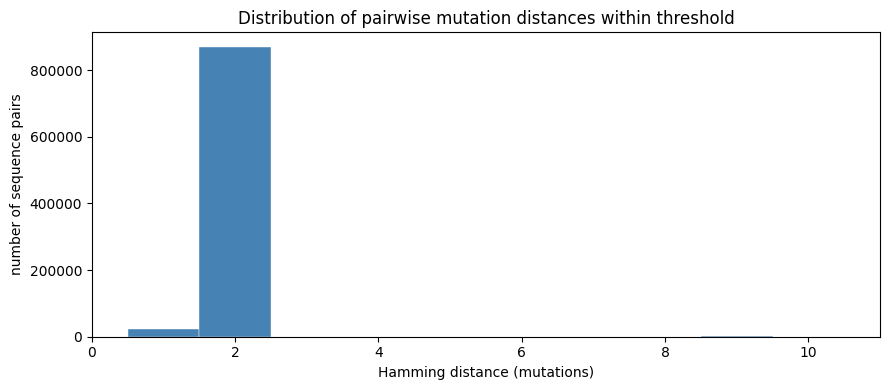

n_mutations
1      22318
2     869504
3         17
4          9
5          6
6        168
7          6
8        311
9       2433
10         6


In [9]:
edge_df = pd.DataFrame(all_edges, columns=['idx_i', 'idx_j', 'n_mutations'])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(edge_df['n_mutations'], bins=MAX_MUTATIONS, range=(0.5, MAX_MUTATIONS + 0.5),
        color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Hamming distance (mutations)')
ax.set_ylabel('number of sequence pairs')
ax.set_title('Distribution of pairwise mutation distances within threshold')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print(edge_df['n_mutations'].value_counts().sort_index().to_string())

## Save cluster assignments

Serialise cluster IDs back to a CSV for use in training.

In [10]:
out = train[['seq_id', 'cluster_id']].copy()
out['in_multi_cluster'] = out['cluster_id'].isin(multi_clusters.index)
out.to_csv('../data/02_processed/train_cluster_ids.csv', index=False)
print(f'Saved to data/02_processed/train_cluster_ids.csv')
print(out['in_multi_cluster'].value_counts().to_string())

Saved to data/02_processed/train_cluster_ids.csv
in_multi_cluster
False    24290
True      7100
